In [49]:
#import pakages

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
#load dataset

In [51]:
customers = pd.read_csv("Ecommerce Customers.csv") 

In [5]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [8]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [9]:
customers.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [53]:
#EDA  Exploratory Data Analysis

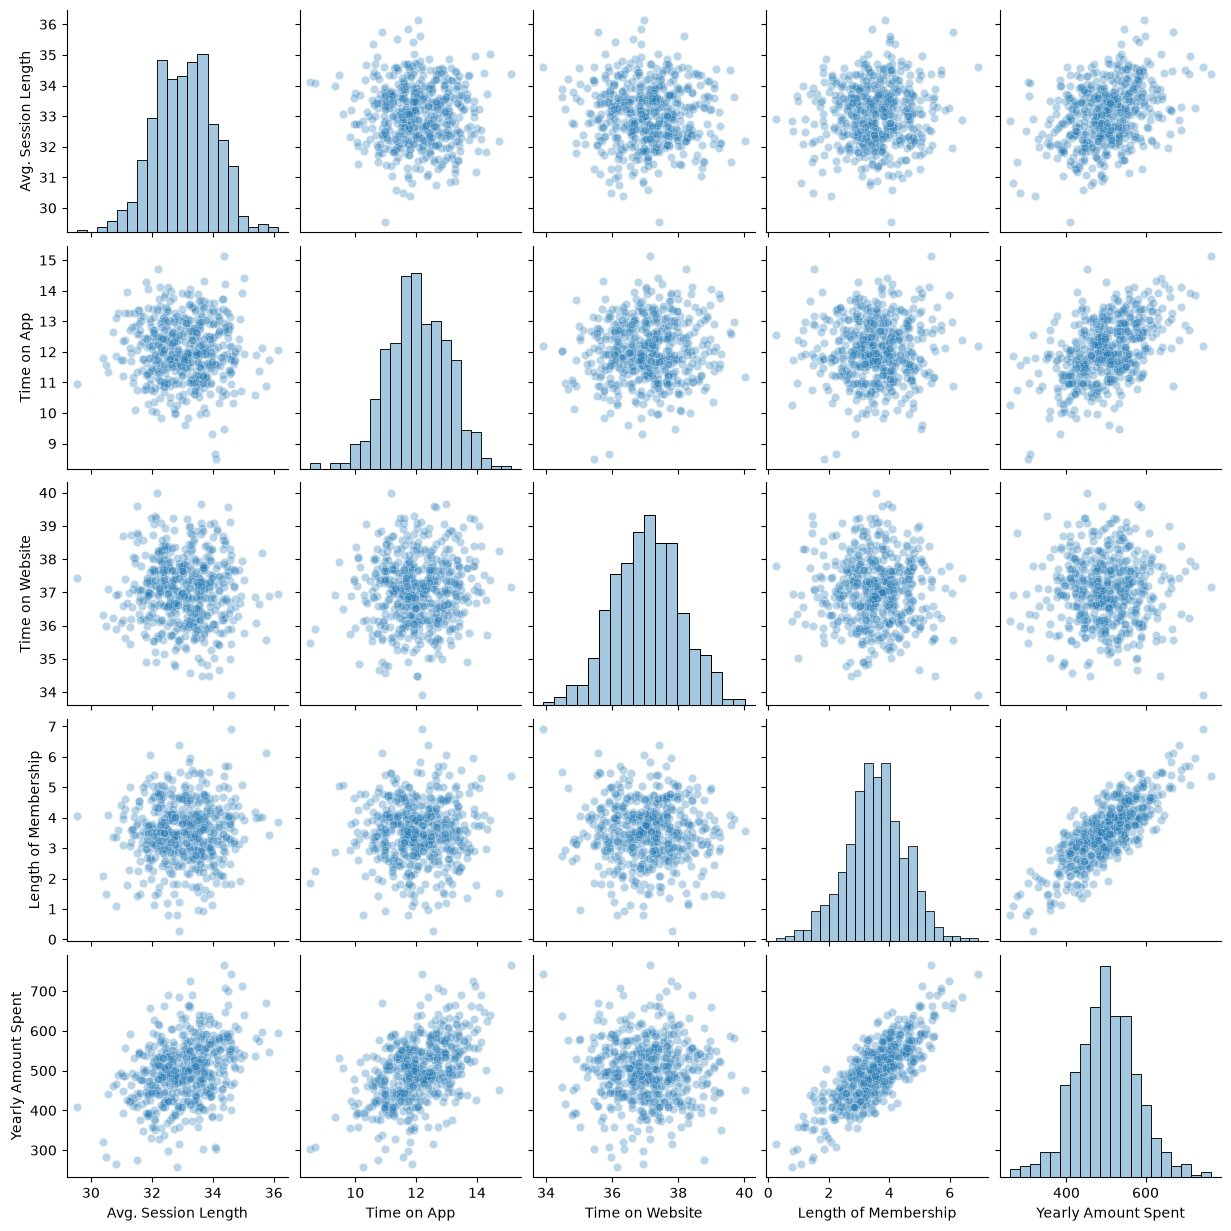

In [11]:
sns.pairplot(customers,
            kind = "scatter",
            plot_kws = {'alpha' : 0.3},
            diag_kws = {'alpha' : 0.4})

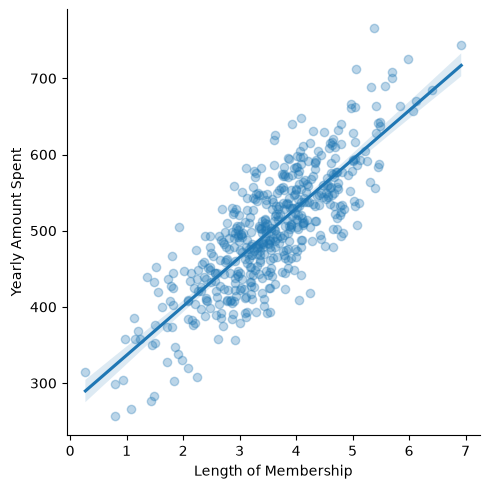

In [17]:
sns.lmplot(x = "Length of Membership",
          y = "Yearly Amount Spent",
          data = customers,
          scatter_kws={'alpha' : 0.3})

In [54]:
#Splitting the data

In [20]:
from sklearn.model_selection import train_test_split

In [22]:
X = customers[[
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]]
y = customers["Yearly Amount Spent"]

In [23]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [55]:
#Training the Model with multivariable regression using Scikit Learn

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()

In [27]:
model.fit(X_train,y_train);

In [28]:
model.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [30]:
model.score(X_train,y_train)

0.9854085989105928

In [32]:
cef = pd.DataFrame(model.coef_,X.columns,columns = ["coef"])
print(cef)

                           coef
Avg. Session Length   25.724256
Time on App           38.597135
Time on Website        0.459148
Length of Membership  61.674732


In [33]:
#prediction

In [34]:
pred = model.predict(X_test)

Text(0.5, 1.0, 'Yearly amount Spent vs model prediction')

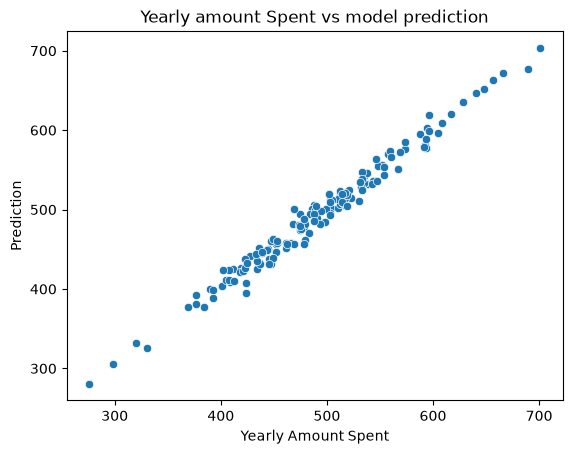

In [37]:
sns.scatterplot(x=y_test,y=pred)
plt.ylabel("Prediction")
plt.title("Yearly amount Spent vs model prediction")

In [56]:
#evaluation

In [38]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [45]:
print(f"MAE     :{mean_absolute_error(y_test,pred):.2f}")
print(f"MSE     :{mean_squared_error(y_test,pred):.2f}")
print(f"r2 score: {r2_score(y_test,pred):.2f}")
print(f"Slope   : {model.coef_[0]:.2f}")
print(f"intercept : {model.intercept_:.2f}")

MAE     :8.43
MSE     :103.92
r2 score: 0.98
Slope   : 25.72
intercept : -1050.65


In [48]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9854085989105928
0.9808757641125855
